In [4]:
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, train_test_split

# Data road

In [5]:
base_df = pd.read_excel("A_SPEQT.xlsx")
base_df

,Sample_G,no,Group,Age,Sex,Bedtime9_1,WUT_9,Time_dataset,Insomnia,Hypnotics,...,ISI_total,ISI_G,DBSTq2_av,SPRIS_av,SPAIS_av,SMYTH_av,SMORE_av,SATIS_av,SATIS_G,SATIS_13
0,S2025_006,5031,1,23,2,1,1,1,1,1,...,0,1,1.0,5.000000,5.833333,6.0,5.9,6.000000,6,6
1,S2025_006,10577,2,54,1,1,1,1,1,1,...,3,1,1.5,5.166667,8.000000,5.4,6.0,5.928571,6,6
2,S2025_006,2632,1,33,2,1,0,0,1,1,...,6,1,5.0,4.000000,8.666667,1.1,2.9,4.714286,5,5
3,S2025_006,10684,2,64,2,1,1,1,1,1,...,6,1,9.0,5.833333,9.166667,6.5,9.0,9.357143,10,10
4,S2025_006,16381,2,26,1,1,0,0,1,1,...,7,1,0.5,5.833333,7.666667,2.4,6.3,7.500000,7,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,S2025_006,1837,1,41,1,1,1,1,1,1,...,28,4,10.0,6.333333,8.666667,1.5,3.0,6.785714,7,7
496,S2025_006,10326,2,37,2,1,1,1,1,1,...,28,4,10.0,6.666667,9.333333,7.5,3.7,4.142857,10,10
497,S2025_006,249,1,35,2,1,1,1,1,1,...,28,4,10.0,8.833333,10.000000,5.3,8.9,6.571429,5,5
498,S2025_006,10088,2,37,1,1,1,1,1,1,...,28,4,10.0,8.666667,9.166667,9.2,4.9,2.785714,3,3


# Algorithm Implementation

In [6]:
# CatBoost model

def make_cat_model_from_user_params(user_params: dict):
    p = dict(user_params)

    if "bagging_temperature" in p:
        p["bootstrap_type"] = "Bayesian"

    if "early_stopping_rounds" in p:
        p.pop("od_wait", None)
        p.pop("od_type", None)

    return CatBoostRegressor(**p)


# =========================================================
# 1) OOF evaluator with memoization
# =========================================================
class OOFCacheEvaluator:
    def __init__(self, base_df, target_cols, user_params,
                 n_splits=5, shuffle=True, random_state=42):

        self.base_df = base_df
        self.target_cols = list(target_cols)
        self.user_params = dict(user_params)

        idx = base_df.index.to_numpy()
        kf = KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
        self.splits = [(idx[tr], idx[va]) for tr, va in kf.split(idx)]

        # Cache: feature set -> {target: OOF_R2}
        self.cache = {}

    def eval_feature_set(self, features):
        key = tuple(sorted(features))
        if key in self.cache:
            return self.cache[key]

        X = self.base_df[list(features)]
        out = {}

        for t in self.target_cols:
            y = self.base_df[t]
            oof_pred = pd.Series(index=self.base_df.index, dtype=float)

            for tr_idx, va_idx in self.splits:
                model = make_cat_model_from_user_params(self.user_params)
                model.fit(
                    X.loc[tr_idx], y.loc[tr_idx],
                    eval_set=(X.loc[va_idx], y.loc[va_idx]),
                    use_best_model=True,
                    verbose=False
                )
                oof_pred.loc[va_idx] = model.predict(X.loc[va_idx])

            out[t] = float(r2_score(y, oof_pred))

        self.cache[key] = out
        return out


# =========================================================
# 2) Greedy - PART 1: choose 1 item by maximizing sum OOF R²
# =========================================================
def select_first_item_by_sum_oof(
    evaluator: OOFCacheEvaluator,
    candidate_items,
    target_cols
):
    candidate_items = list(candidate_items)
    target_cols = list(target_cols)

    best_item, best_sum, best_r2s = None, -np.inf, None
    for j in candidate_items:
        r2s = evaluator.eval_feature_set([j])
        score = sum(r2s[t] for t in target_cols)
        if score > best_sum:
            best_sum, best_item, best_r2s = score, j, r2s

    selected = [best_item]
    row = {
        "k": 1,
        "picked": best_item,
        "mode": "step1_sumOOF_R2",
        "sumOOF_R2": float(best_sum),
        "weakest_target": min(best_r2s, key=best_r2s.get),
        "delta_weakest": np.nan,
    }
    for t in target_cols:
        row[f"OOF_R2_{t}"] = float(best_r2s[t])

    hist = pd.DataFrame([row])
    return selected, hist


# =========================================================
# 3) Greedy - PART 2/3: continue by improving weakest target
#     (resume-capable)
# =========================================================
def continue_greedy_on_weakest_oof(
    evaluator: OOFCacheEvaluator,
    candidate_items,
    target_cols,
    k_total,
    start_selected,
    start_hist
):
    candidate_items = list(candidate_items)
    target_cols = list(target_cols)

    selected = list(start_selected)
    history = start_hist.copy()

    remaining = [x for x in candidate_items if x not in selected]

    while len(selected) < k_total and remaining:
        base_r2s = evaluator.eval_feature_set(selected)
        t_star = min(base_r2s, key=base_r2s.get)
        baseline = float(base_r2s[t_star])

        best_c, best_delta, best_new_r2s = None, -np.inf, None
        for c in remaining:
            new_r2s = evaluator.eval_feature_set(selected + [c])
            delta = float(new_r2s[t_star] - baseline)
            if delta > best_delta:
                best_delta, best_c, best_new_r2s = delta, c, new_r2s

        selected.append(best_c)
        remaining.remove(best_c)

        row = {
            "k": len(selected),
            "picked": best_c,
            "mode": "stepk_delta_on_weakest_OOF",
            "weakest_target": t_star,
            "baseline_OOF_R2_weakest": baseline,
            "new_OOF_R2_weakest": float(best_new_r2s[t_star]),
            "delta_weakest": float(best_delta),
        }
        # (optional) sumOOF_R2도 같이 기록
        row["sumOOF_R2"] = float(sum(best_new_r2s[t] for t in target_cols))

        for t in target_cols:
            row[f"OOF_R2_{t}"] = float(best_new_r2s[t])

        history = pd.concat([history, pd.DataFrame([row])], ignore_index=True)

        print(f"[k={len(selected):02d}] picked={best_c:>18s}  weakest={t_star}  "
              f"baseline={baseline:.4f}  new={best_new_r2s[t_star]:.4f}  delta={best_delta:.4f}")

    return selected, history


# =========================================================
# 4) Plot & save
# =========================================================
def plot_and_save_oof_curves(hist_df, target_cols,
                            out_dir="figures", fname="oof_r2_by_k"):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    k = hist_df["k"].to_numpy()

    # Target-wise curves
    plt.figure(figsize=(10, 5))
    for t in target_cols:
        plt.plot(k, hist_df[f"OOF_R2_{t}"], marker="o", linewidth=2, label=t)

    plt.xlabel("Number of selected items (k)")
    plt.ylabel("OOF R²")
    plt.xticks(k)
    plt.grid(True, linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / f"{fname}.png", dpi=300)
    plt.savefig(out_dir / f"{fname}.pdf")
    plt.show()

    # Mean curve
    plt.figure(figsize=(10, 5))
    vals = np.vstack([hist_df[f"OOF_R2_{t}"] for t in target_cols])
    plt.plot(k, vals.mean(axis=0), marker="o", linewidth=2)

    plt.xlabel("Number of selected items (k)")
    plt.ylabel("Mean OOF R²")
    plt.xticks(k)
    plt.grid(True, linewidth=0.5)
    plt.tight_layout()
    plt.savefig(out_dir / f"{fname}_mean.png", dpi=300)
    plt.savefig(out_dir / f"{fname}_mean.pdf")
    plt.show()

    return str(out_dir)

# Model setting

In [8]:
# (1) Candidate questionnaire items
candidate_items = [
    # SPRIS
    "SPRIS_1", "SPRIS_2", "SPRIS_3", "SPRIS_4", "SPRIS_5", "SPRIS_6",
    # SPAIS
    "SPAIS_1", "SPAIS_2", "SPAIS_3", "SPAIS_4", "SPAIS_5", "SPAIS_6",
    # SMYTH
    "SMYTH_1", "SMYTH_2", "SMYTH_3", "SMYTH_4", "SMYTH_5",
    "SMYTH_6", "SMYTH_7", "SMYTH_8", "SMYTH_9", "SMYTH_10",
    # SMORE
    "SMORE_1", "SMORE_2", "SMORE_3", "SMORE_4", "SMORE_5",
    "SMORE_6", "SMORE_7", "SMORE_8", "SMORE_9", "SMORE_10",
    # SATIS
    "SATIS_1", "SATIS_2", "SATIS_3", "SATIS_4", "SATIS_5", "SATIS_6",
    "SATIS_7", "SATIS_8", "SATIS_9", "SATIS_10", "SATIS_11", "SATIS_12",
    "SATIS_13_Global_item", "SATIS_14", "SATIS_15"
]

# (2) Target variables
target_cols = ["SPRIS_av", "SPAIS_av", "SMYTH_av", "SMORE_av", "SATIS_av"]

# (3) CatBoost hyperparameters
user_params = dict(
    loss_function="RMSE",
    iterations=8000,
    learning_rate=0.002887502882062776,
    depth=3,
    l2_leaf_reg=9.576593911651704,
    bagging_temperature=0.03296057975269804,
    random_strength=2.1363388482181613,
    rsm=0.8897141011558393,
    min_data_in_leaf=28,
    random_seed=42,
    early_stopping_rounds=200,
    verbose=200,
    thread_count=-1,
)

# (4) Fixed evaluation set
fixed_cols = list(candidate_items) + list(target_cols)
print("Fixed-base n =", len(base_df))

# (5) Evaluator
evaluator = OOFCacheEvaluator(
    base_df=base_df,
    target_cols=target_cols,
    user_params=user_params,
    n_splits=5,
    shuffle=True,
    random_state=42
)

Fixed-base n = 500


# Algorithm Run

In [9]:
selected_1, hist_1 = select_first_item_by_sum_oof(
    evaluator=evaluator,
    candidate_items=candidate_items,
    target_cols=target_cols
)

print("\n[PART 1] Selected (k=1):", selected_1)

os.makedirs("cache_runs", exist_ok=True)
joblib.dump(
    {"selected": selected_1, "hist": hist_1, "evaluator_cache": evaluator.cache},
    "cache_runs/state_k1.pkl"
)
print("Saved -> cache_runs/state_k1.pkl")


[PART 1] Selected (k=1): ['SMORE_6']
Saved -> cache_runs/state_k1.pkl


In [10]:
K_mid = 9   

state = joblib.load("cache_runs/state_k1.pkl")
evaluator.cache.update(state.get("evaluator_cache", {}))

selected_mid, hist_mid = continue_greedy_on_weakest_oof(
    evaluator=evaluator,
    candidate_items=candidate_items,
    target_cols=target_cols,
    k_total=K_mid,
    start_selected=state["selected"],
    start_hist=state["hist"],
)

print(f"\n[PART 2] Selected (k=1..{K_mid}):")
print(selected_mid)

joblib.dump(
    {"selected": selected_mid, "hist": hist_mid, "evaluator_cache": evaluator.cache},
    f"cache_runs/state_k{K_mid}.pkl"
)
print(f"Saved -> cache_runs/state_k{K_mid}.pkl")

[k=02] picked=           SPRIS_6  weakest=SPRIS_av  baseline=0.0736  new=0.5234  delta=0.4498
[k=03] picked=           SMYTH_8  weakest=SMYTH_av  baseline=0.0657  new=0.6564  delta=0.5907
[k=04] picked=           SPAIS_5  weakest=SPAIS_av  baseline=0.2951  new=0.7660  delta=0.4709
[k=05] picked=          SATIS_15  weakest=SATIS_av  baseline=0.3461  new=0.6706  delta=0.3245
[k=06] picked=           SPRIS_3  weakest=SPRIS_av  baseline=0.5335  new=0.7693  delta=0.2359
[k=07] picked=           SMYTH_4  weakest=SMYTH_av  baseline=0.6537  new=0.8197  delta=0.1660
[k=08] picked=           SATIS_5  weakest=SATIS_av  baseline=0.6728  new=0.7794  delta=0.1066
[k=09] picked=           SMORE_4  weakest=SMORE_av  baseline=0.7115  new=0.8582  delta=0.1467

[PART 2] Selected (k=1..9):
['SMORE_6', 'SPRIS_6', 'SMYTH_8', 'SPAIS_5', 'SATIS_15', 'SPRIS_3', 'SMYTH_4', 'SATIS_5', 'SMORE_4']
Saved -> cache_runs/state_k9.pkl


In [11]:
K_total = 16

state2 = joblib.load(f"cache_runs/state_k{K_mid}.pkl")
evaluator.cache.update(state2.get("evaluator_cache", {}))

selected_final, hist_final = continue_greedy_on_weakest_oof(
    evaluator=evaluator,
    candidate_items=candidate_items,
    target_cols=target_cols,
    k_total=K_total,
    start_selected=state2["selected"],
    start_hist=state2["hist"],
)

print(f"\n[PART 3] Selected (k=1..{K_total}):")
print(selected_final)

print("\nSelection history (summary):")
show_cols = ["k", "picked", "mode"]
print(hist_final[show_cols].fillna("").to_string(index=False))

[k=10] picked=           SPAIS_3  weakest=SPAIS_av  baseline=0.7551  new=0.8761  delta=0.1210
[k=11] picked=           SPRIS_5  weakest=SPRIS_av  baseline=0.7670  new=0.8652  delta=0.0982
[k=12] picked=           SATIS_9  weakest=SATIS_av  baseline=0.7962  new=0.8679  delta=0.0717
[k=13] picked=           SMYTH_3  weakest=SMYTH_av  baseline=0.8267  new=0.9016  delta=0.0749
[k=14] picked=           SMORE_8  weakest=SMORE_av  baseline=0.8535  new=0.9076  delta=0.0541
[k=15] picked=           SPRIS_1  weakest=SPRIS_av  baseline=0.8631  new=0.9163  delta=0.0532
[k=16] picked=          SATIS_11  weakest=SATIS_av  baseline=0.8678  new=0.9012  delta=0.0335

[PART 3] Selected (k=1..16):
['SMORE_6', 'SPRIS_6', 'SMYTH_8', 'SPAIS_5', 'SATIS_15', 'SPRIS_3', 'SMYTH_4', 'SATIS_5', 'SMORE_4', 'SPAIS_3', 'SPRIS_5', 'SATIS_9', 'SMYTH_3', 'SMORE_8', 'SPRIS_1', 'SATIS_11']

Selection history (summary):
 k   picked                       mode
 1  SMORE_6            step1_sumOOF_R2
 2  SPRIS_6 stepk_delta_o

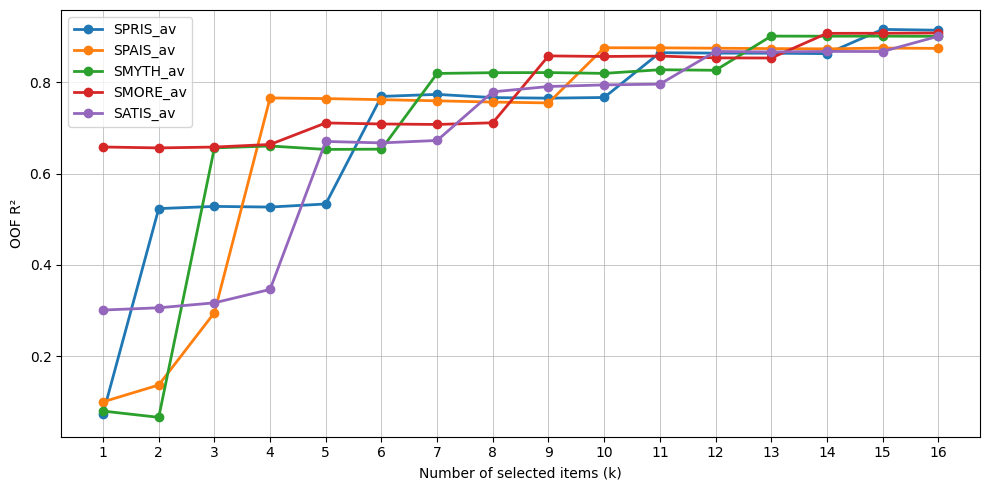

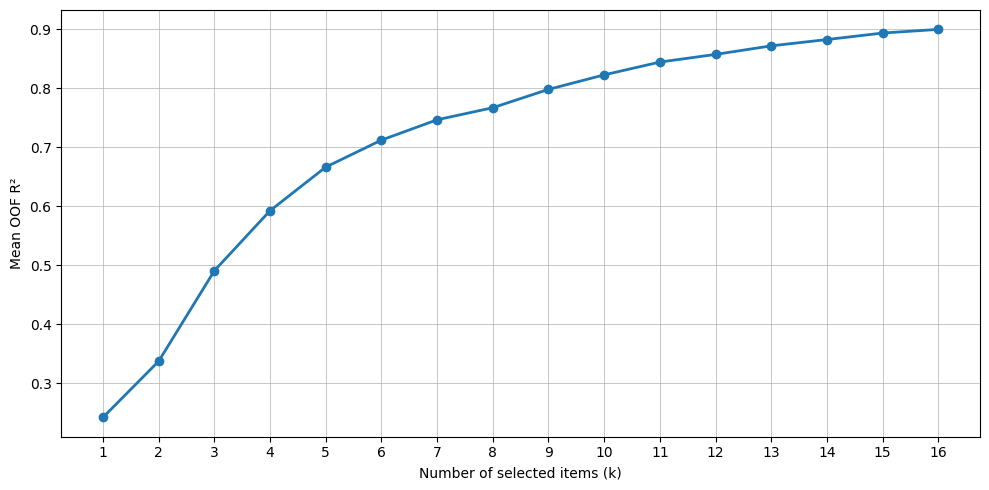


Saved figures to: figures


In [12]:
out_dir = plot_and_save_oof_curves(
    hist_df=hist_final,
    target_cols=target_cols,
    out_dir="figures",
    fname="oof_r2_by_k"
)
print("\nSaved figures to:", out_dir)